In [2]:
# Import necessary libraries
import pandas as pd
from collections import defaultdict
import geopandas as gpd
from shapely import wkt
import shapely

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pickle
%matplotlib inline
import datetime
import time
import numpy as np
import xml.etree.ElementTree as ET 
import matsim

import utm
from shapely.geometry import Polygon, Point
import gzip
from matplotlib import cm

import matplotlib.ticker as ticker
import matplotlib.font_manager as font_manager
import matplotlib as mpl
from matplotlib.lines import Line2D
from tqdm import tqdm
from matplotlib.colors import LinearSegmentedColormap


In [4]:
# Create a dictionary linking each area type code to its description
area_type_dict = {
    1: "Metropolitan Center",
    2: "High-Density Residential Use",
    3: "Dense Mixed Use",
    4: "Residential Use",
    5: "Industrial Use",
    6: "Urbanized Periphery",
    7: "Rural with Industrial Influence",
    8: "Rural without Industrial Influence"
}

from matplotlib.colors import to_hex
# Define the desired order of legend labels in English
# Create a dictionary linking each category to a color



category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}



category_color_dict_num = {
    0: "#482878",
    1: "#3f4989",
    2: "#31688e",
    3: "#26828e",
    4: "#1f9e89",
    5: "#35b779",
    6: "#6fce58",
    7: "#b5de2b"
}



# Create a dictionary linking each category to a color
category_color = {category: i / (len(category_color_dict) - 1) for i, category in enumerate(category_color_dict)}

# Create the colormap
cmap = LinearSegmentedColormap.from_list("custom_cmap", sns.color_palette("viridis_r", len(category_color_dict))[::-1])

# Convert the colormap to a dictionary
palette_dict = {cat: to_hex(cmap(category_color[cat])) for cat in category_color_dict}


In [ ]:
result = pd.read_csv("result_2.csv")



def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'

# Umbenennen der Spalten für besser lesbare KPIs
rename_map = {
    'tour_km': 'Tour Length (km)',
    'Tour Duration': 'Tour Duration (hrs)',
    'Travel Duration': 'Driving Time (hrs)',
    'vehicle_load_factor': 'Vehicle Utilization (%)',
    'initial_delivery_distance': 'Initial Delivery Distance (km)',
    'avg_dist_wo_init': 'Mean Distance Between Stops (km)'
}
result = result.rename(columns=rename_map)

# Konvertiere Sekunden → Stunden (nur wenn noch nicht konvertiert)
for col in ['Tour Duration (hrs)', 'Driving Time (hrs)']:
    result[col] = result[col] / 3600

# Durchschnittsgeschwindigkeit berechnen (km/h)
result['Average Speed (km/h)'] = result['Tour Length (km)'] / result['Driving Time (hrs)']

result['main_area_type_agg'] = result['main_area_type'].apply(determine_area_type)
# Prozentualer Anteil der reinen Fahrzeit an der Gesamttourdauer
result['Driving Share of Tour (%)'] = (result['Driving Time (hrs)'] / result['Tour Duration (hrs)']) * 100

def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'
    
result['area_type_agg'] = result['main_area_type'].apply(determine_area_type)
result['main_area_description'] = result['main_area_type'].map(area_type_dict)
bc = result

In [25]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Simplify column names for formula use
def simplify_name(name):
    return name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("-", "").replace("/", "").replace("%", "pct")

# Eta²-Hilfsfunktion
def compute_eta_squared(df, group_col, target_col):
    formula = f"{target_col} ~ C({group_col})"
    model = smf.ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    eta_sq = anova_table['sum_sq'][0] / anova_table['sum_sq'].sum()
    return eta_sq

# Deine KPIs
readable_kpis = [
    'Tour Length (km)',
    'Tour Duration (hrs)',
    'Driving Time (hrs)',
    'Initial Delivery Distance (km)',
    'avg_dist_with_init',
    'Mean Distance Between Stops (km)',
    'max_dist_wo_init',
    'Vehicle Utilization (%)',
    'Average Speed (km/h)',
    'Driving Share of Tour (%)',
    'b2b_ration',
    'vehicle_cost',
    'deliveries_per_stop'
]

# Mapping lesbar → technisch
name_map = {col: simplify_name(col) for col in readable_kpis}
inverse_name_map = {v: k for k, v in name_map.items()}

# Kopie des DataFrames mit umbenannten Spalten
df_simplified = result.rename(columns=name_map).copy()

# ANOVA auf technischer Spaltenbasis
clean_df = df_simplified.dropna(subset=list(name_map.values()) + ['main_area_type'])

eta_results = {
    col: compute_eta_squared(clean_df, 'main_area_type', col)
    for col in name_map.values()
}

# Ergebnis mit lesbaren Namen zurückgeben
eta_df_all = pd.DataFrame.from_dict(eta_results, orient='index', columns=['eta_squared']) \
                         .rename(index=inverse_name_map) \
                         .sort_values(by='eta_squared', ascending=False)
eta_df_all.index.name = "Variable"

eta_df_all

# Interpretation of eta_squared (Effect Size according to Cohen, 1988):
# ---------------------------------------------------------------------
# η² < 0.01       → negligible effect
# 0.01–0.06       → small effect
# 0.06–0.14       → medium effect
# > 0.14          → large effect
#
# This means: A higher eta_squared value indicates that the grouping variable 
# (e.g., main_area_type) explains a larger proportion of the variance in the target variable.
# Example: η² = 0.18 → 18% of the variance is explained by area type → large effect.



C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_24472\3454199226.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eta_sq = anova_table['sum_sq'][0] / anova_table['sum_sq'].sum()
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_24472\3454199226.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eta_sq = anova_table['sum_sq'][0] / anova_table['sum_sq'].sum()
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_24472\3454199226.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). T

,eta_squared
Variable,
Tour Length (km),0.195606
Average Speed (km/h),0.193791
max_dist_wo_init,0.178543
Driving Share of Tour (%),0.171954
Mean Distance Between Stops (km),0.164057
deliveries_per_stop,0.153507
Driving Time (hrs),0.122375
Initial Delivery Distance (km),0.079611
Vehicle Utilization (%),0.072372


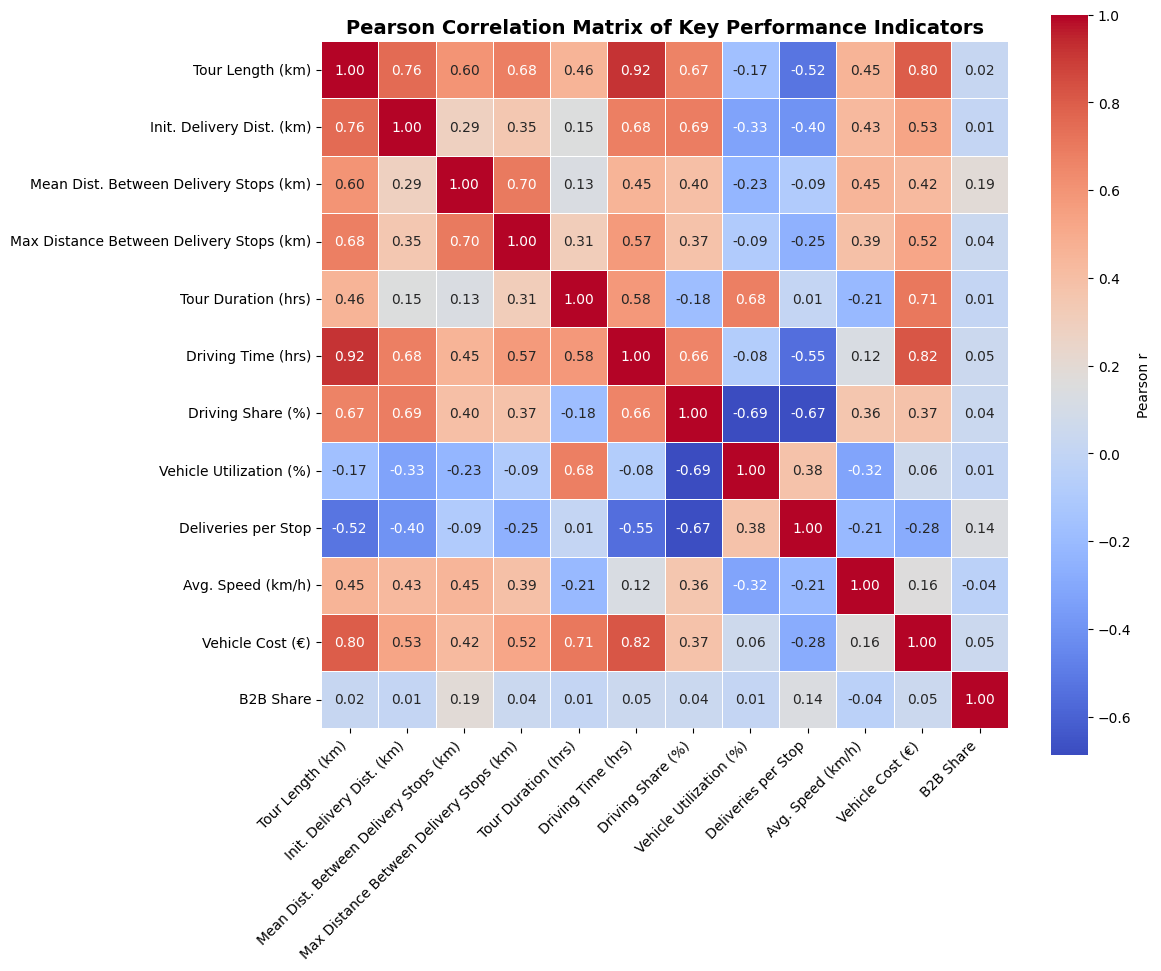

In [26]:
# Manuelle Reihenfolge der Variablen (logische Gruppierung)
sorted_readable_kpis = [
    "Tour Length (km)",
    "Initial Delivery Distance (km)",
    "Mean Distance Between Stops (km)",
    "max_dist_wo_init",
    "Tour Duration (hrs)",
    "Driving Time (hrs)",
    "Driving Share of Tour (%)",
    "Vehicle Utilization (%)",
    "deliveries_per_stop",
    "Average Speed (km/h)",
    "vehicle_cost",
    "b2b_ration"
]

# Schönere Beschriftungen
label_map = {
    "Tour Length (km)": "Tour Length (km)",
    "Initial Delivery Distance (km)": "Init. Delivery Dist. (km)",
    "Mean Distance Between Stops (km)": "Mean Dist. Between Delivery Stops (km)",
    "max_dist_wo_init": "Max Distance Between Delivery Stops (km)",
    "Tour Duration (hrs)": "Tour Duration (hrs)",
    "Driving Time (hrs)": "Driving Time (hrs)",
    "Driving Share of Tour (%)": "Driving Share (%)",
    "Vehicle Utilization (%)": "Vehicle Utilization (%)",
    "deliveries_per_stop": "Deliveries per Stop",
    "Average Speed (km/h)": "Avg. Speed (km/h)",
    "vehicle_cost": "Vehicle Cost (€)",
    "b2b_ration": "B2B Share"
}

import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Select simplified KPI columns
kpi_columns_simplified = list(name_map.values())
correlation_df = df_simplified[kpi_columns_simplified].dropna()

# Step 2: Calculate Pearson correlation matrix
correlation_matrix = correlation_df.corr(method='pearson')

# Optional: Rename back to readable names
correlation_matrix.index = [inverse_name_map.get(c, c) for c in correlation_matrix.index]
correlation_matrix.columns = [inverse_name_map.get(c, c) for c in correlation_matrix.columns]

# Step 3: Display correlation matrix
correlation_matrix

# Neu sortierte und benannte Matrix
sorted_kpis = [label_map.get(k, k) for k in sorted_readable_kpis]
corr_sorted = correlation_matrix.loc[sorted_readable_kpis, sorted_readable_kpis]
corr_sorted.index = sorted_kpis
corr_sorted.columns = sorted_kpis

# Heatmap erzeugen
plt.figure(figsize=(12, 10))
sns.heatmap(corr_sorted, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5,
            cbar_kws={"label": "Pearson r"})
plt.title("Pearson Correlation Matrix of Key Performance Indicators", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()



In [27]:
import pandas as pd
import numpy as np
from scipy import stats

# Kopie für MANOVA-Analyse
df_manova = bc.copy()

# Gruppierungsvariable (ggf. umbenennen)
df_manova['AreaType'] = df_manova['main_area_type']

# Transformationen
df_manova['Tour_Length_log'] = np.log(df_manova['Tour Length (km)'] + 1)
df_manova['Avg_Speed_BoxCox'], _ = stats.boxcox(df_manova['Average Speed (km/h)'].clip(lower=0.1))

area_cluster_mapping = {
    1: 'Urban',
    2: 'Urban',
    3: 'Urban',
    4: 'Suburban',
    5: 'Suburban',
    6: 'Suburban',
    7: 'Rural',
    8: 'Rural'
}

df_manova['AreaType_agg'] = df_manova['AreaType'].map(area_cluster_mapping)



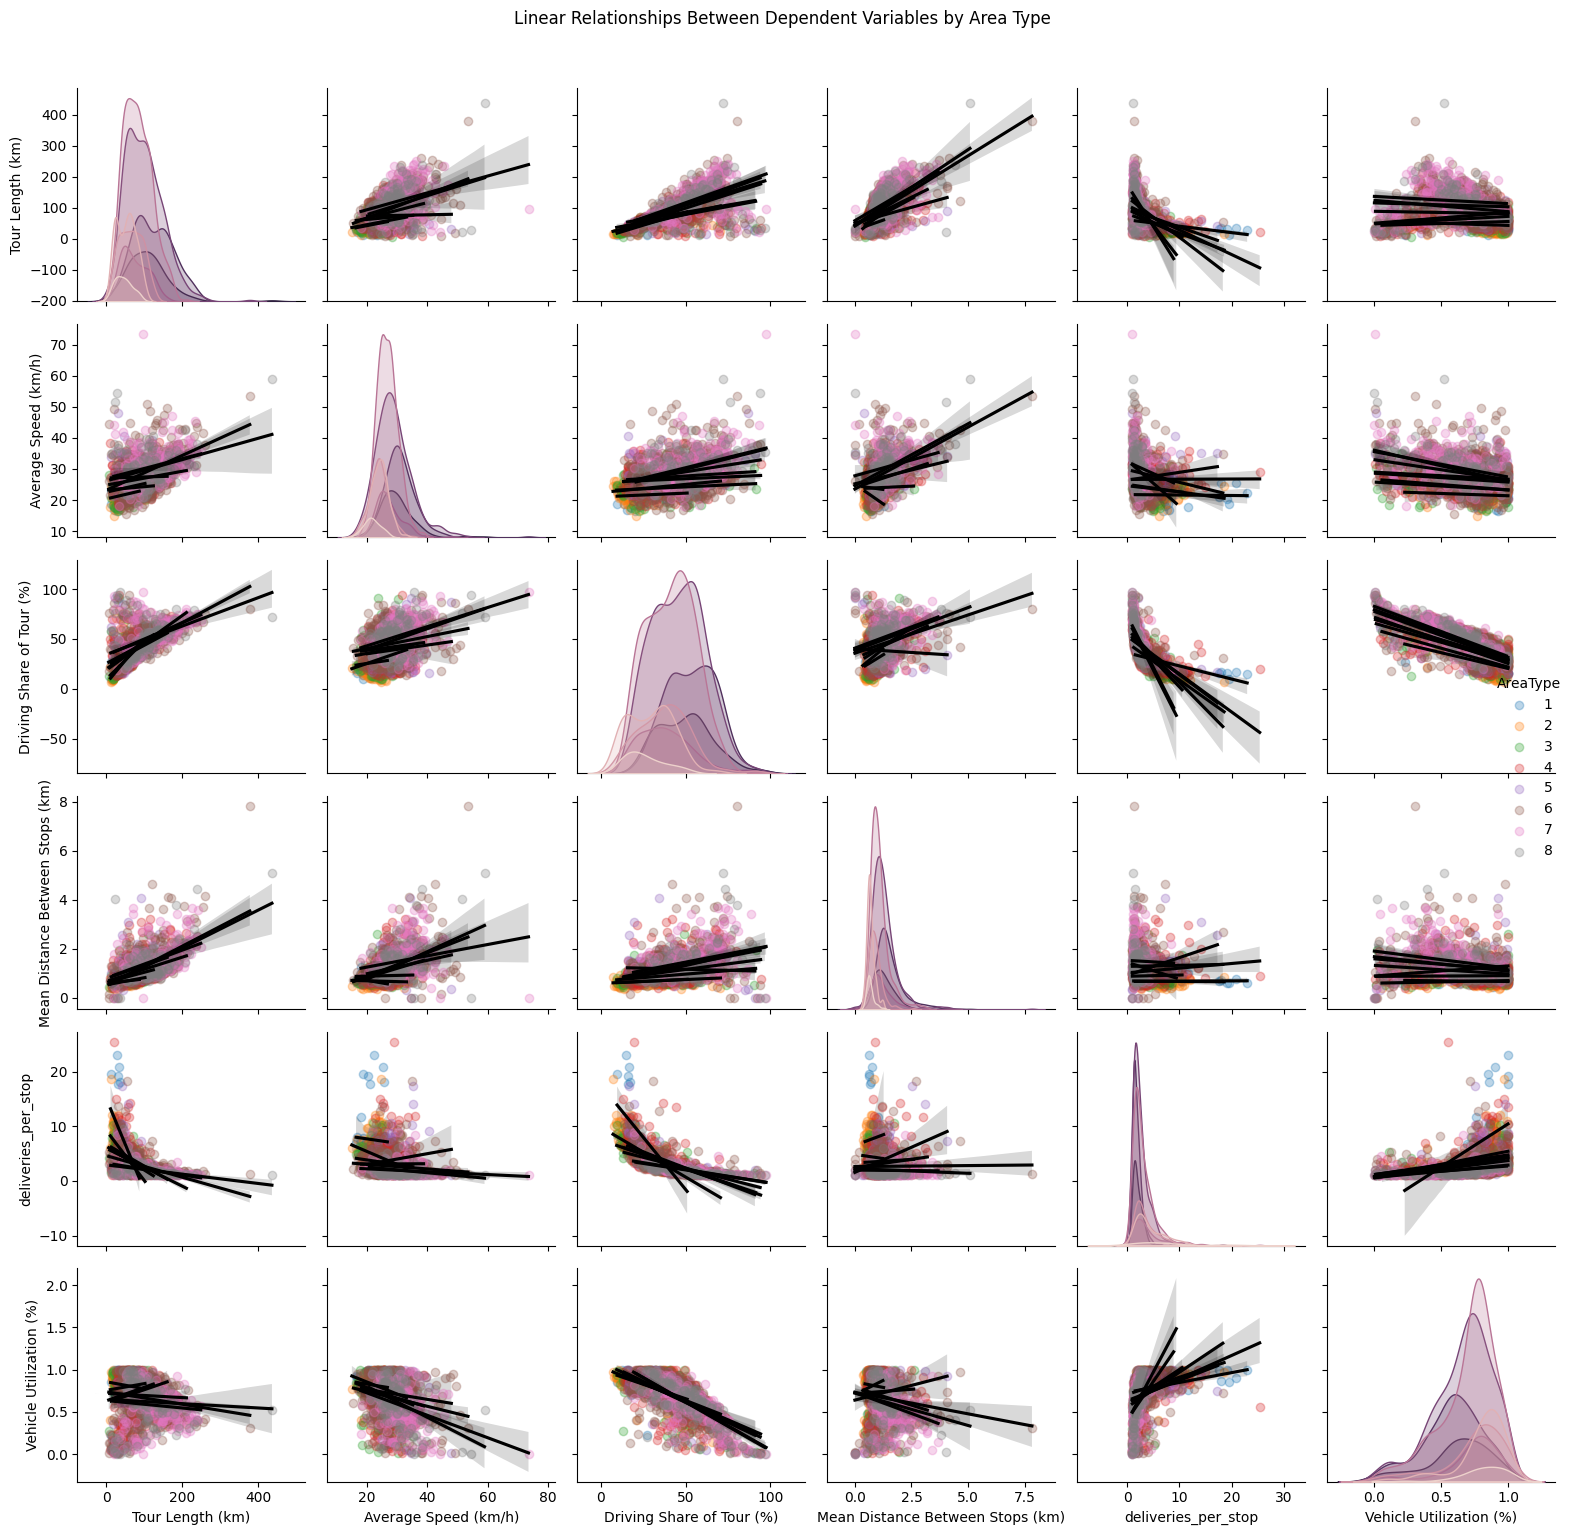


Pearson-Korrelationen für Gruppe: 1
                                  Tour Length (km)  Average Speed (km/h)  \
Tour Length (km)                              1.00                  0.23   
Average Speed (km/h)                          0.23                  1.00   
Driving Share of Tour (%)                     0.88                  0.10   
Mean Distance Between Stops (km)              0.20                 -0.33   
deliveries_per_stop                          -0.59                 -0.03   
Vehicle Utilization (%)                      -0.11                 -0.09   

                                  Driving Share of Tour (%)  \
Tour Length (km)                                       0.88   
Average Speed (km/h)                                   0.10   
Driving Share of Tour (%)                              1.00   
Mean Distance Between Stops (km)                       0.21   
deliveries_per_stop                                   -0.71   
Vehicle Utilization (%)                             

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Deine umbenannten abhängigen Variablen
dv = [
    "Tour Length (km)",
    "Average Speed (km/h)",
    "Driving Share of Tour (%)",
    "Mean Distance Between Stops (km)",
    "deliveries_per_stop",
    "Vehicle Utilization (%)"
]

# Unabhängige Variable
iv = 'AreaType'

# Pairplot mit Hue für AreaType
sns.pairplot(df_manova, vars=dv, hue=iv, kind='reg',
             plot_kws={'line_kws': {'color': 'black'}, 'scatter_kws': {'alpha': 0.3}})
plt.suptitle("Linear Relationships Between Dependent Variables by Area Type", y=1.02)
plt.tight_layout()
plt.show()

grouped = df_manova.groupby(iv)

for name, group in grouped:
    print(f"\nPearson-Korrelationen für Gruppe: {name}")
    corr = group[dv].corr()
    print(corr.round(2))


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2, zscore

# Deine abhängigen Variablen
dv = [
    "Tour Length (km)",
    "Average Speed (km/h)",
    "Driving Share of Tour (%)",
    "Mean Distance Between Stops (km)",
    "deliveries_per_stop",
    "Vehicle Utilization (%)"
]

# -------- 1. UNIVARIATE OUTLIERS --------
print("Univariate Ausreißer (Boxplots + Z-Scores):\n")
for var in dv:
    # Boxplot anzeigen
    # sns.boxplot(x=df_manova[var])
    # plt.title(f"Boxplot für {var}")
    # plt.show()

    # Z-Scores berechnen und Fälle mit |Z| > 3 markieren
    z_scores = zscore(df_manova[var].dropna())
    outliers = np.where(np.abs(z_scores) > 3)[0]
    print(f"{len(outliers)} univariate Ausreißer in '{var}' (|Z| > 3)\n")

# -------- 2. MULTIVARIATE OUTLIERS (Mahalanobis Distance) --------
print("\nMultivariate Ausreißer (Mahalanobis-Distanz):")

# Matrix der abhängigen Variablen
X = df_manova[dv].dropna()

# Mahalanobis-Distanzen berechnen
cov_matrix = np.cov(X, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)
mean_vals = X.mean().values

mahal_dists = X.apply(lambda row: mahalanobis(row, mean_vals, inv_cov_matrix), axis=1)

# Chi²-Schwellenwert (df = Anzahl Variablen)
threshold = chi2.ppf(0.999, df=X.shape[1])
print(f"Schwellenwert (Chi², df={X.shape[1]}, alpha=0.001): {threshold:.2f}")

# Ausreißer identifizieren
outlier_indices = mahal_dists[mahal_dists > threshold].index
print(f"{len(outlier_indices)} multivariate Ausreißer erkannt.\n")

# Optional: In Original-DF markieren
df_manova["Multivariate_Outlier"] = False
df_manova.loc[outlier_indices, "Multivariate_Outlier"] = True


Univariate Ausreißer (Boxplots + Z-Scores):

13 univariate Ausreißer in 'Tour Length (km)' (|Z| > 3)

23 univariate Ausreißer in 'Average Speed (km/h)' (|Z| > 3)

6 univariate Ausreißer in 'Driving Share of Tour (%)' (|Z| > 3)

33 univariate Ausreißer in 'Mean Distance Between Stops (km)' (|Z| > 3)

35 univariate Ausreißer in 'deliveries_per_stop' (|Z| > 3)

0 univariate Ausreißer in 'Vehicle Utilization (%)' (|Z| > 3)


Multivariate Ausreißer (Mahalanobis-Distanz):
Schwellenwert (Chi², df=6, alpha=0.001): 22.46
0 multivariate Ausreißer erkannt.



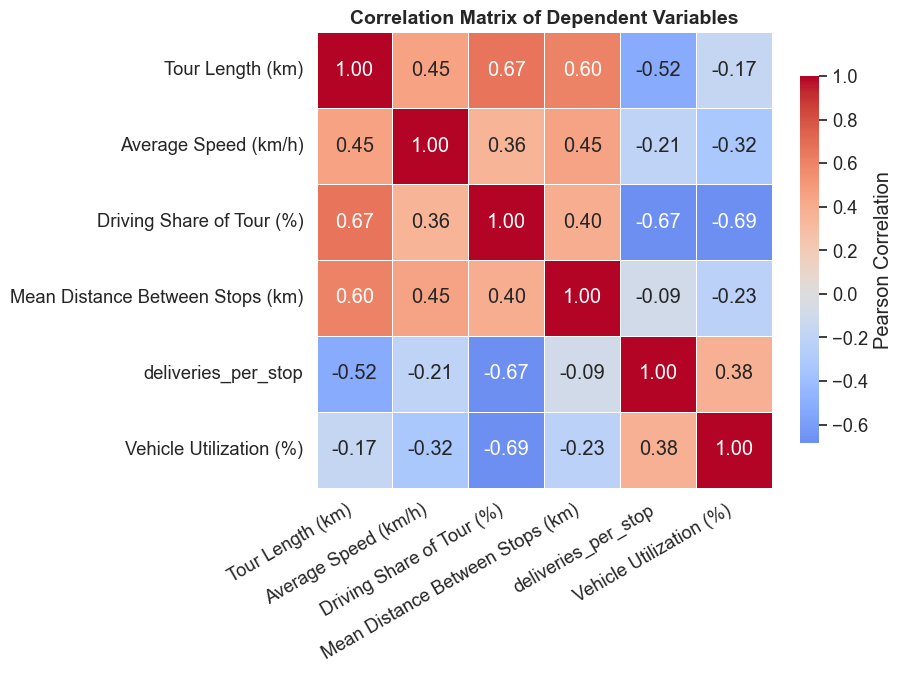

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Liste der abhängigen Variablen
dv = [
    "Tour Length (km)",
    "Average Speed (km/h)",
    "Driving Share of Tour (%)",
    "Mean Distance Between Stops (km)",
    "deliveries_per_stop",
    "Vehicle Utilization (%)"
]

# Korrelationsmatrix berechnen
corr_matrix = df_manova[dv].corr(method='pearson')

# Plot-Stil anpassen für wissenschaftliche Darstellung
sns.set(style="white", font_scale=1.2)

# Heatmap mit maskierter Oberhälfte (da Matrix symmetrisch ist)
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Farbpalette und Plot
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    # mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"}
)

plt.title("Correlation Matrix of Dependent Variables", fontsize=14, weight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [31]:
from scipy.stats import levene

# Deine finale Liste der abhängigen Variablen
dv_final = [
    "Tour Length (km)",
    "Average Speed (km/h)",
    "Driving Share of Tour (%)",
    "Mean Distance Between Stops (km)",
    "deliveries_per_stop",
    "Vehicle Utilization (%)"
]

# Gruppierungsvariable
group_col = 'AreaType'

# Levene-Test für jede Variable
for var in dv_final:
    # Gruppenwerte extrahieren
    groups = [group[var].dropna() for _, group in df_manova.groupby(group_col)]
    
    # Levene-Test durchführen
    stat, p = levene(*groups, center='median')  # 'median' ist robuster als 'mean'
    
    print(f"{var:35}  Levene p = {p:.4f}  {'✓' if p > 0.05 else '✗'}")


Tour Length (km)                     Levene p = 0.0000  ✗
Average Speed (km/h)                 Levene p = 0.0000  ✗
Driving Share of Tour (%)            Levene p = 0.1530  ✓
Mean Distance Between Stops (km)     Levene p = 0.0000  ✗
deliveries_per_stop                  Levene p = 0.0000  ✗
Vehicle Utilization (%)              Levene p = 0.0166  ✗


In [ ]:
from scipy.stats import boxcox, levene
import numpy as np

# Kopie für Transformationen
df_check = df_manova.copy()
df_check = df_check.dropna(subset=[
    "Tour Length (km)",
    "Average Speed (km/h)",
    "Driving Share of Tour (%)",
    "Mean Distance Between Stops (km)",
    "deliveries_per_stop",
    "Vehicle Utilization (%)",
    'AreaType'
])

# Transformationen vorbereiten – angepasst an df_check
transformations = {}

for col in [
    "Tour Length (km)",
    "Average Speed (km/h)",
    "Driving Share of Tour (%)",
    "Mean Distance Between Stops (km)",
    "deliveries_per_stop",
    "Vehicle Utilization (%)",
]:
    series = df_check[col] + 1  # Avoid log(0) or boxcox(0)
    series = series.replace([np.inf, -np.inf], np.nan).dropna()

    # Box-Cox nur für positive Werte erlaubt
    if (series <= 0).any():
        print(f"⚠️ Skipping Box-Cox for {col} due to non-positive values.")
        continue

    transformations[col] = {
        'log': np.log(series),
        'boxcox': boxcox(series)[0]
    }

# Levene-Tests ausführen
print("Levene-Test für Log- und Box-Cox-Transformationen:\n")
for var, trans in transformations.items():
    print(f"{var}:")
    for method, transformed_data in trans.items():
        df_check['__temp__'] = transformed_data
        groups = [g['__temp__'] for _, g in df_check.groupby('AreaType')]
        stat, p = levene(*groups, center='median')
        print(f"  {method.ljust(6)}  p = {p:.4f}  {'✓' if p > 0.05 else '✗'}")
    print()


Levene-Test für Log- und Box-Cox-Transformationen:

Tour Length (km):
  log     p = 0.3723  ✓
  boxcox  p = 0.0067  ✗

Average Speed (km/h):
  log     p = 0.0000  ✗
  boxcox  p = 0.0000  ✗

Driving Share of Tour (%):
  log     p = 0.0000  ✗
  boxcox  p = 0.5234  ✓

Mean Distance Between Stops (km):
  log     p = 0.0000  ✗
  boxcox  p = 0.0000  ✗

deliveries_per_stop:
  log     p = 0.0000  ✗
  boxcox  p = 0.0012  ✗

Vehicle Utilization (%):
  log     p = 0.0033  ✗
  boxcox  p = 0.2369  ✓



In [36]:
from scipy.stats import levene, boxcox
from sklearn.preprocessing import PowerTransformer
import numpy as np
import pandas as pd

df_check = df_check.dropna(subset=['AreaType'])  # Sicherstellen, dass Gruppierung funktioniert

# Liste aller numerischen KPIs (ohne AreaType und vehicle_id etc.)
numeric_vars = df_check.select_dtypes(include=[np.number]).columns.drop('AreaType')

# Ausgabe vorbereiten
results = []

for var in numeric_vars:
    x = df_check[var].dropna()
    if (x <= 0).any():
        x_pos = x + abs(x.min()) + 1  # für BoxCox/Reciprocal/Log
    else:
        x_pos = x + 1

    # Erzeuge Spalten für Transformationen
    df_check[f'{var}_log'] = np.log(x_pos)
    df_check[f'{var}_sqrt'] = np.sqrt(x_pos)
    df_check[f'{var}_reciprocal'] = 1 / x_pos
    try:
        df_check[f'{var}_boxcox'], _ = boxcox(x_pos)
    except:
        df_check[f'{var}_boxcox'] = np.nan  # falls BoxCox fehlschlägt (z.B. zu wenig Varianz)

    yeo = PowerTransformer(method='yeo-johnson')
    try:
        df_check[f'{var}_yeojohnson'] = yeo.fit_transform(x.values.reshape(-1, 1)).flatten()
    except:
        df_check[f'{var}_yeojohnson'] = np.nan

    # Levene-Test für jede Transformation
    for method in ['log', 'boxcox', 'sqrt', 'reciprocal', 'yeojohnson']:
        colname = f"{var}_{method}"
        if colname not in df_check.columns:
            continue
        if df_check[colname].isna().all():
            continue

        groups = [g[colname].dropna() for _, g in df_check.groupby('AreaType')]
        try:
            stat, p = levene(*groups, center='median')
            results.append({
                'Variable': var,
                'Transformation': method,
                'Levene_p': p,
                'Homoscedastic': p > 0.05
            })
        except:
            continue

# Ergebnisse als DataFrame anzeigen
levene_df = pd.DataFrame(results).sort_values(by=['Variable', 'Levene_p'], ascending=[True, False])
levene_df


c:\Users\bienzeisler\Anaconda3\envs\matsim_geo_environment\lib\site-packages\scipy\stats\_morestats.py:3057: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom
c:\Users\bienzeisler\Anaconda3\envs\matsim_geo_environment\lib\site-packages\scipy\stats\_morestats.py:3057: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom
c:\Users\bienzeisler\Anaconda3\envs\matsim_geo_environment\lib\site-packages\scipy\stats\_morestats.py:3057: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom
c:\Users\bienzeisler\Anaconda3\envs\matsim_geo_environment\lib\site-packages\scipy\stats\_morestats.py:3057: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom
c:\Users\bienzeisler\Anaconda3\envs\matsim_geo_environment\lib\site-packages\scipy\stats\_morestats.py:3057: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom
c:\Users\bienzeisler\Anaconda3\envs\matsim_geo_environment\l

,Variable,Transformation,Levene_p,Homoscedastic
145,Average Speed (km/h),reciprocal,9.387128e-09,False
146,Average Speed (km/h),yeojohnson,1.918434e-10,False
143,Average Speed (km/h),boxcox,1.918433e-10,False
142,Average Speed (km/h),log,4.857295e-14,False
144,Average Speed (km/h),sqrt,2.247032e-17,False
...,...,...,...,...
94,vehicle_time_cost,sqrt,4.996254e-01,True
92,vehicle_time_cost,log,4.488838e-01,True
95,vehicle_time_cost,reciprocal,3.152341e-01,True
96,vehicle_time_cost,yeojohnson,1.785745e-01,True


In [40]:
from scipy.stats import boxcox, levene
from statsmodels.multivariate.manova import MANOVA
import numpy as np
import pandas as pd

# Arbeitskopie
df_mbox = df_manova.copy()

# Liste deiner Zielvariablen
target_vars = [
    "Tour Length (km)",
    "Average Speed (km/h)",
    "Driving Share of Tour (%)",
    "Mean Distance Between Stops (km)",
    "deliveries_per_stop",
    "Vehicle Utilization (%)"
]

# Levene-Test-Ergebnisse + Transformationen
final_vars = []
transformed_cols = {}

for var in target_vars:
    series = df_mbox[var].copy()
    x_pos = series + 1

    # Box-Cox Transformation
    try:
        boxcox_transformed, _ = boxcox(x_pos)
        df_mbox[f'{var}_boxcox'] = boxcox_transformed
        groups_box = [g[f'{var}_boxcox'].dropna() for _, g in df_mbox.groupby('AreaType')]
        p_box = levene(*groups_box, center='median').pvalue
    except:
        p_box = 0

    # Log Transformation
    try:
        df_mbox[f'{var}_log'] = np.log(x_pos)
        groups_log = [g[f'{var}_log'].dropna() for _, g in df_mbox.groupby('AreaType')]
        p_log = levene(*groups_log, center='median').pvalue
    except:
        p_log = 0

    # Entscheidung treffen
    if p_log > 0.05:
        final_vars.append(f'{var}_log')
        transformed_cols[f'{var}_log'] = var
    elif p_box > 0.00001:
        final_vars.append(f'{var}_boxcox')
        transformed_cols[f'{var}_boxcox'] = var
    else:
        final_vars.append(var)  # untransformiert

# Formel bauen
formula = ' + '.join([f'Q("{v}")' if ' ' in v else v for v in final_vars]) + ' ~ AreaType'

# MANOVA
maov = MANOVA.from_formula(formula, data=df_mbox)

# Ausgabe
print("✅ Final variables used in MANOVA (with transformation decisions):")
for v in final_vars:
    base = transformed_cols.get(v, v)
    trans = 'log' if '_log' in v else 'boxcox' if '_boxcox' in v else 'none'
    print(f"  - {base:<35} → {trans}")

print("\n🎯 MANOVA results:\n")
print(maov.mv_test())


✅ Final variables used in MANOVA (with transformation decisions):
  - Tour Length (km)                    → log
  - Average Speed (km/h)                → none
  - Driving Share of Tour (%)           → boxcox
  - Mean Distance Between Stops (km)    → none
  - deliveries_per_stop                 → boxcox
  - Vehicle Utilization (%)             → boxcox

🎯 MANOVA results:

                     Multivariate linear model
                                                                   
-------------------------------------------------------------------
       Intercept         Value   Num DF   Den DF   F Value   Pr > F
-------------------------------------------------------------------
          Wilks' lambda   0.0094 6.0000 1737.0000 30535.4435 0.0000
         Pillai's trace   0.9906 6.0000 1737.0000 30535.4435 0.0000
 Hotelling-Lawley trace 105.4765 6.0000 1737.0000 30535.4435 0.0000
    Roy's greatest root 105.4765 6.0000 1737.0000 30535.4435 0.0000
------------------------------------

In [46]:
import pandas as pd
from rpy2.robjects import pandas2ri, r
from rpy2.robjects.packages import importr
pandas2ri.activate()

# Vorbereitung: Variablennamen vereinfachen (R-kompatibel, keine Leerzeichen oder Sonderzeichen)
df_rmanova = df_mbox[['AreaType', 'AreaType_agg']].copy()

# Verwende die korrekten Spaltennamen
df_rmanova['tour_length_log']        = df_mbox['Tour_Length_log']
df_rmanova['average_speed']          = df_mbox['Average Speed (km/h)']
df_rmanova['driving_share_boxcox']   = df_mbox['Driving Share of Tour (%)_boxcox']
df_rmanova['mean_dist_raw']          = df_mbox['Mean Distance Between Stops (km)']
df_rmanova['deliveries_boxcox']      = df_mbox['deliveries_per_stop_boxcox']
df_rmanova['utilization_boxcox']     = df_mbox['Vehicle Utilization (%)_boxcox']
df_rmanova['id']                     = range(len(df_rmanova))  # Dummy subject ID

# In R übertragen
r_df = pandas2ri.py2rpy(df_rmanova)
r.assign('mydata', r_df)

# Paket laden
r('library(MANOVA.RM)')

# MANOVA mit robustem Wild Bootstrap
r('''
res <- MANOVA.wide(
  formula = cbind(
    tour_length_log,
    average_speed,
    driving_share_boxcox,
    mean_dist_raw,
    deliveries_boxcox,
    utilization_boxcox
  ) ~ AreaType,
  data = mydata,
  subject = "id",
  iter = 1000,
  resampling = "WildBS"
)
print(summary(res))
''')


Call: 
cbind(tour_length_log, average_speed, driving_share_boxcox, mean_dist_raw, 
    deliveries_boxcox, utilization_boxcox) ~ AreaType

Descriptive:
  AreaType   n tour_length_log  average_speed  driving_share_boxcox
1        1  35           3.703         21.672                12.037
2        2 142           3.847         23.988                13.118
3        3 148           4.067         23.941                15.714
4        4 448           4.318         26.664                16.857
5        5 106           4.206         27.356                15.918
6        6 468           4.475         28.714                18.118
7        7 258           4.716         30.871                20.419
8        8 139           4.556         29.840                19.302
   mean_dist_raw  deliveries_boxcox  utilization_boxcox
1          0.678              0.755               2.180
2          0.683              0.713               2.100
3          0.899              0.686               1.885
4          1.

In [47]:
import pandas as pd
from rpy2.robjects import r, pandas2ri
from rpy2.robjects.packages import importr
import rpy2.robjects as ro

# 1. Activate conversion
pandas2ri.activate()

# 2. Import required R packages
biotools = importr('biotools')
base = importr('base')

# 3. Clean up column names
df_r = df_rmanova.copy()  # assumes you already prepared df_rmanova
df_r.columns = df_r.columns.str.replace(r"[^\w]", ".", regex=True)

# 4. Push to R
r_df = pandas2ri.py2rpy(df_r)
ro.globalenv['mydata'] = r_df

# 5. Force locale
r('invisible(Sys.setlocale("LC_ALL", "C"))')

# 6. Define robust BoxM test function with updated variable list
r('''
safe_boxm_pval <- function() {
  suppressMessages({
    suppressWarnings({
      vars <- c("tour_length_log", "average_speed", "driving_share_boxcox",
                "mean_dist_raw", "deliveries_boxcox", "utilization_boxcox")
      if (!all(vars %in% names(mydata))) {
        return(NA)
      }
      result <- tryCatch({
        boxM(mydata[, vars], mydata$AreaType)
      }, error = function(e) {
        return(NULL)
      })
      if (is.null(result)) return(NA)
      if (is.na(result$p.value)) return(NA)
      return(as.numeric(result$p.value))
    })
  })
}
''')

# 7. Run and print result
p_val = r['safe_boxm_pval']()[0]
if p_val is None or p_val == -2147483648 or pd.isna(p_val):
    print("❌ Invalid Box’s M-Test p-value – check variable names and group sizes.")
else:
    print(f"✅ Box’s M-Test p-value: {p_val:.5f}")


✅ Box’s M-Test p-value: 0.00000


In [107]:
import numpy as np
from statsmodels.stats.multivariate import test_cov_oneway

# Deine abhängigen Variablen
# Daten vorbereiten
dv_cols = [
    'Tour_Length_log',
    'Average_speed',
    'Initial_Delivery',
    'Utilization_boxcox'
]

# Gruppierte Daten vorbereiten
grouped_data = []
nobs_list = []
cov_list = []

for _, group in df_rmanova.groupby("AreaType"):
    g = group[dv_cols].dropna().values
    if len(g) <= len(dv_cols):  # Mindestens p+1 Beobachtungen für stabile Kovarianz
        continue
    grouped_data.append(g)
    nobs_list.append(len(g))
    cov_list.append(np.cov(g.T))  # Achtung: Transponieren!

# Test ausführen
test_result = test_cov_oneway(cov_list, nobs_list)

# Ergebnis anzeigen
print(f"📊 test_cov_oneway p-value: {test_result.pvalue:.5f}")
print(test_result)


📊 test_cov_oneway p-value: 0.00000
statistic = 11.344252998622071
pvalue = 5.301272420697171e-123
statistic_base = 805.50371175078
statistic_chi2 = 794.3259094035618
pvalue_chi2 = 2.8044557306471033e-123
df_chi2 = 70.0
distr_chi2 = chi2
statistic_f = 11.344252998622071
pvalue_f = 5.301272420697171e-123
df_f = (70.0, 247087.5695100208)
distr_f = F
tuple = (11.344252998622071, 5.301272420697171e-123)


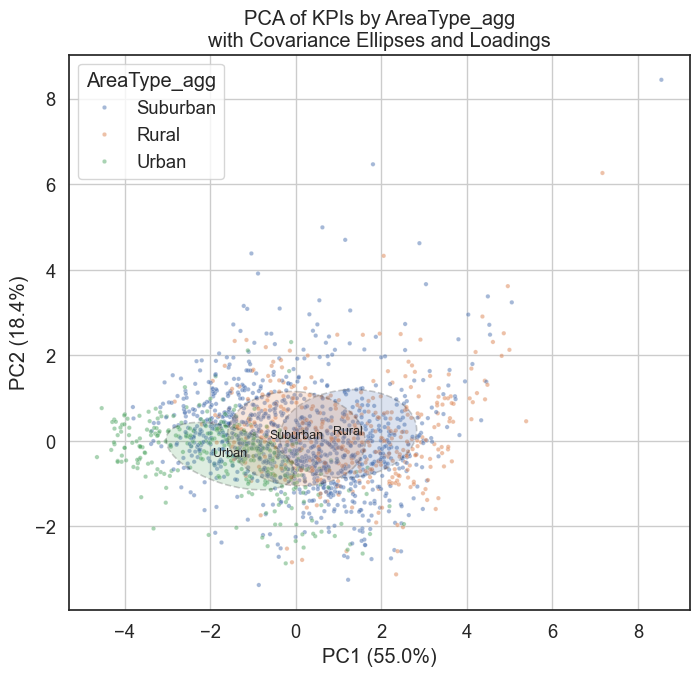

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
import numpy as np

def plot_pca_with_ellipses(pca_df, X_scaled, pca, feature_names, group_col='AreaType_agg', ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))

    # Scatterplot (transparente Punkte)
    palette = sns.color_palette(n_colors=pca_df[group_col].nunique())
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=group_col, ax=ax, s=10, alpha=0.5, palette=palette)

    # Farbzuordnung für Ellipsen
    color_dict = dict(zip(sorted(pca_df[group_col].unique()), palette))

    # Ellipsen je Gruppe
    for name, group in pca_df.groupby(group_col):
        if len(group) < 10:
            continue

        cov = np.cov(group[["PC1", "PC2"]].values.T)
        if np.linalg.det(cov) <= 0:
            continue

        mean = group[["PC1", "PC2"]].mean().values
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]

        angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals)

        ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor='black', facecolor=color_dict[name], alpha=0.2,
                      linestyle='--', linewidth=1.2)
        ax.add_patch(ell)
        ax.text(mean[0], mean[1], str(name), fontsize=9, ha='center')

    # # === Loadings berechnen und als Pfeile einzeichnen ===
    # eigenvectors = pca.components_.T
    # eigenvalues = pca.explained_variance_
    # loadings = eigenvectors * np.sqrt(eigenvalues)

    # for i, feature in enumerate(feature_names):
    #     x, y = loadings[i, 0], loadings[i, 1]
    #     ax.arrow(0, 0, x, y, color='orange', alpha=0.8, head_width=0.03, length_includes_head=True)
    #     ax.text(x * 1.15, y * 1.15, f"{feature}\n({x:.2f}, {y:.2f})", fontsize=9, ha='center', va='center')

    ax.set_title("PCA of KPIs by AreaType_agg\nwith Covariance Ellipses and Loadings")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.grid(True)
    ax.set_aspect('equal')
    plt.tight_layout()
    return ax


# df_rmanova[["Tour_Length_log", "Average_speed", "Initial_Delivery", "Utilization_boxcox"]]

# Daten vorbereiten
dv_cols = [
    'tour_length_log',          # Log-transformed Tour Length
    'average_speed',            # Raw
    'driving_share_boxcox',     # Box-Cox-transformed Driving Share
    'mean_dist_raw',            # Raw Mean Distance Between Stops
    'deliveries_boxcox',        # Box-Cox-transformed Deliveries per Stop
    'utilization_boxcox'        # Box-Cox-transformed Vehicle Utilization
]
df_plot = df_rmanova.dropna(subset=dv_cols + ['AreaType'])


features = [
    'tour_length_log',          # Log-transformed Tour Length
    'average_speed',            # Raw
    'driving_share_boxcox',     # Box-Cox-transformed Driving Share
    'mean_dist_raw',            # Raw Mean Distance Between Stops
    'deliveries_boxcox',        # Box-Cox-transformed Deliveries per Stop
    'utilization_boxcox'        # Box-Cox-transformed Vehicle Utilization
]
df_plot = df_rmanova.dropna(subset=features + ['AreaType_agg'])
X_scaled = StandardScaler().fit_transform(df_plot[features])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# PCA-DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["AreaType_agg"] = df_plot["AreaType_agg"].values


# Ergebnis in DataFrame packen
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["AreaType"] = df_plot["AreaType"].astype(str)
pca_df["AreaType_agg"] = df_plot["AreaType_agg"].values

ax = plot_pca_with_ellipses(pca_df, X_scaled, pca, features, group_col='AreaType_agg')

plt.show()


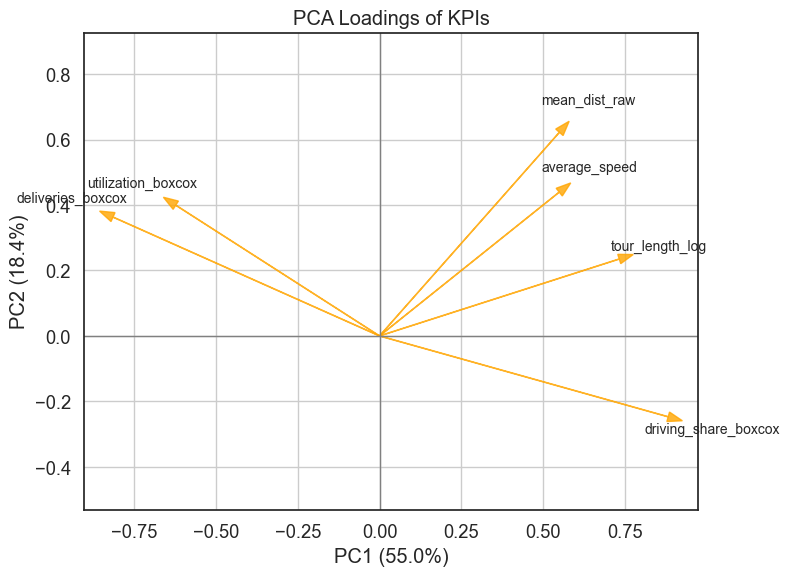

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---- Step 1: PCA vorbereiten ----
features = [
    'tour_length_log',          # Log-transformed Tour Length
    'average_speed',            # Raw
    'driving_share_boxcox',     # Box-Cox-transformed Driving Share
    'mean_dist_raw',            # Raw Mean Distance Between Stops
    'deliveries_boxcox',        # Box-Cox-transformed Deliveries per Stop
    'utilization_boxcox'        # Box-Cox-transformed Vehicle Utilization
]

X = df_rmanova[features].dropna()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ---- Step 2: Loadings berechnen ----
# Eigenvektoren * sqrt(Eigenwerte)
eigenvectors = pca.components_.T
eigenvalues = pca.explained_variance_
loadings = eigenvectors * np.sqrt(eigenvalues)

# ---- Step 3: Visualisieren ----
plt.figure(figsize=(8, 6))
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

# Pfeile für jeden KPI
for i, feature in enumerate(features):
    x, y = loadings[i, 0], loadings[i, 1]
    plt.arrow(0, 0, x, y, color='orange', alpha=0.8, head_width=0.03, length_includes_head=True)
    plt.text(x * 1.1, y * 1.1, feature, fontsize=10, ha='center', va='center')

# Plot-Einstellungen
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA Loadings of KPIs")
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()


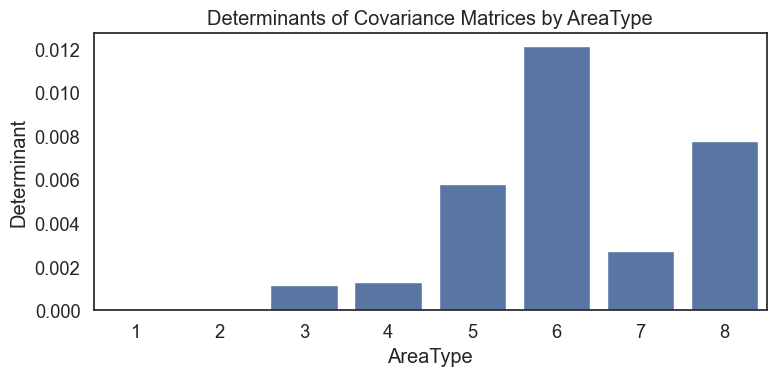

In [54]:
import numpy as np

# Kovarianzmatrizen + Determinanten je Gruppe
det_per_group = {}
for name, group in df_plot.groupby("AreaType"):
    g = group[dv_cols].dropna().values
    if len(g) <= len(dv_cols): continue
    cov = np.cov(g.T)
    det = np.linalg.det(cov)
    det_per_group[name] = det

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(x=list(det_per_group.keys()), y=list(det_per_group.values()))
plt.title("Determinants of Covariance Matrices by AreaType")
plt.xlabel("AreaType")
plt.ylabel("Determinant")
plt.tight_layout()
plt.show()



=== Tukey HSD for tour_length_log ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2   0.1438 0.8268 -0.1544  0.442  False
     1      3   0.3637 0.0051  0.0667 0.6607   True
     1      4   0.6151    0.0  0.3378 0.8924   True
     1      5   0.5028    0.0  0.1948 0.8108   True
     1      6    0.772    0.0  0.4951 1.0489   True
     1      7    1.013    0.0  0.7284 1.2976   True
     1      8   0.8532    0.0  0.5544 1.1521   True
     2      3   0.2199  0.008  0.0343 0.4055   True
     2      4   0.4713    0.0  0.3191 0.6234   True
     2      5    0.359    0.0  0.1562 0.5618   True
     2      6   0.6282    0.0  0.4768 0.7796   True
     2      7   0.8692    0.0  0.7041 1.0343   True
     2      8   0.7094    0.0  0.5209  0.898   True
     3      4   0.2514    0.0  0.1016 0.4012   True
     3      5   0.1391 0.4157  -0.062 0.3401  False
     3      6   0.4083   

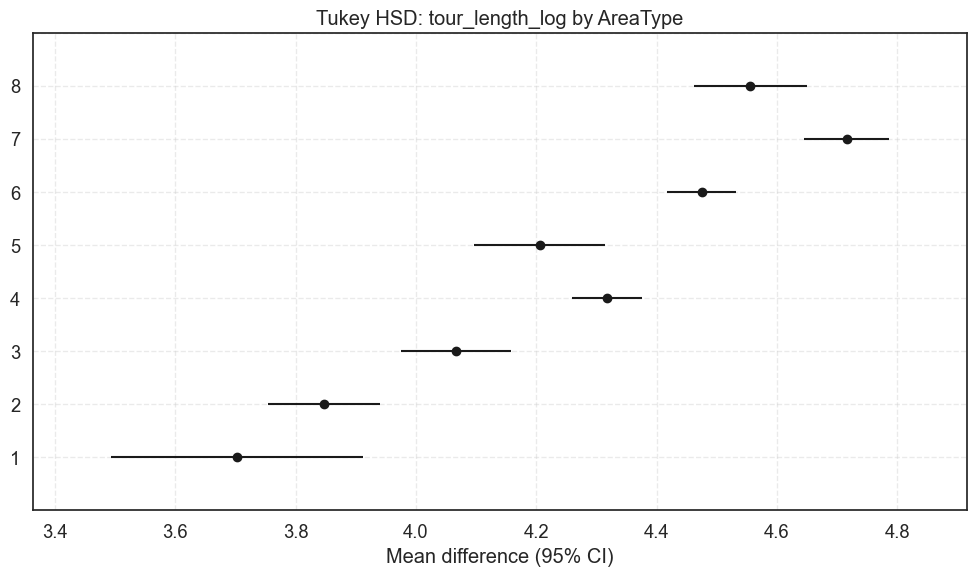


=== Tukey HSD for average_speed ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2   2.3169 0.1665 -0.4156  5.0495  False
     1      3   2.2699  0.183 -0.4517  4.9915  False
     1      4   4.9929    0.0  2.4516  7.5343   True
     1      5   5.6847    0.0  2.8619  8.5075   True
     1      6   7.0424    0.0   4.505  9.5798   True
     1      7   9.1999    0.0  6.5917 11.8082   True
     1      8   8.1686    0.0  5.4302  10.907   True
     2      3   -0.047    1.0 -1.7479  1.6539  False
     2      4    2.676    0.0  1.2815  4.0705   True
     2      5   3.3678    0.0  1.5092  5.2264   True
     2      6   4.7255    0.0  3.3382  6.1128   True
     2      7    6.883    0.0    5.37   8.396   True
     2      8   5.8517    0.0   4.124  7.5793   True
     3      4    2.723    0.0  1.3502  4.0958   True
     3      5   3.4148    0.0  1.5723  5.2572   True
     3   

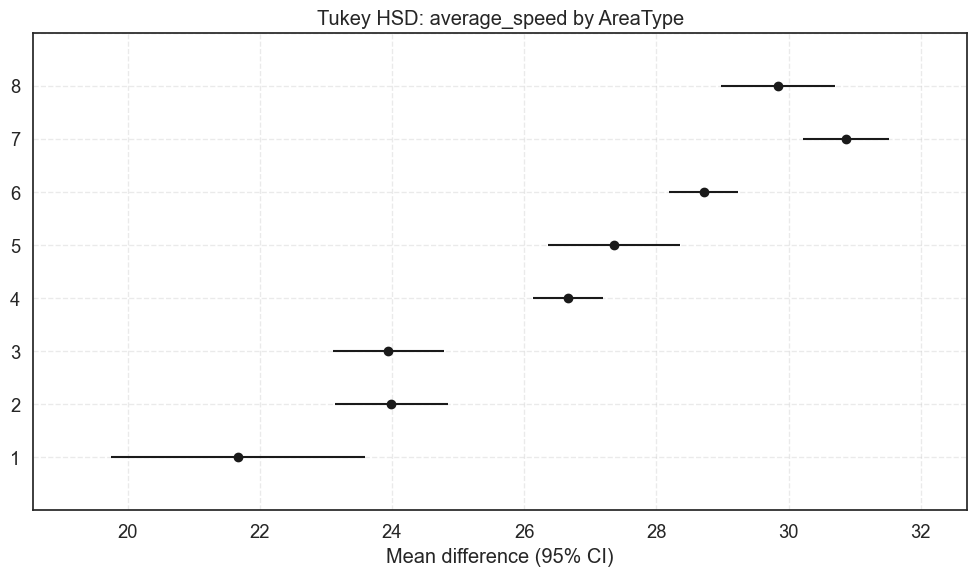


=== Tukey HSD for driving_share_boxcox ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2   1.0812 0.9037 -1.4675    3.63  False
     1      3   3.6772 0.0003  1.1387  6.2156   True
     1      4     4.82    0.0  2.4497  7.1904   True
     1      5   3.8811 0.0002  1.2481   6.514   True
     1      6   6.0809    0.0  3.7143  8.4476   True
     1      7   8.3821    0.0  5.9493 10.8149   True
     1      8   7.2645    0.0  4.7103  9.8186   True
     2      3   2.5959    0.0  1.0094  4.1824   True
     2      4   3.7388    0.0  2.4382  5.0394   True
     2      5   2.7998    0.0  1.0662  4.5334   True
     2      6   4.9997    0.0  3.7058  6.2936   True
     2      7   7.3008    0.0  5.8896  8.7121   True
     2      8   6.1832    0.0  4.5718  7.7947   True
     3      4   1.1429 0.1206 -0.1376  2.4233  False
     3      5   0.2039    1.0 -1.5146  1.9224  False
  

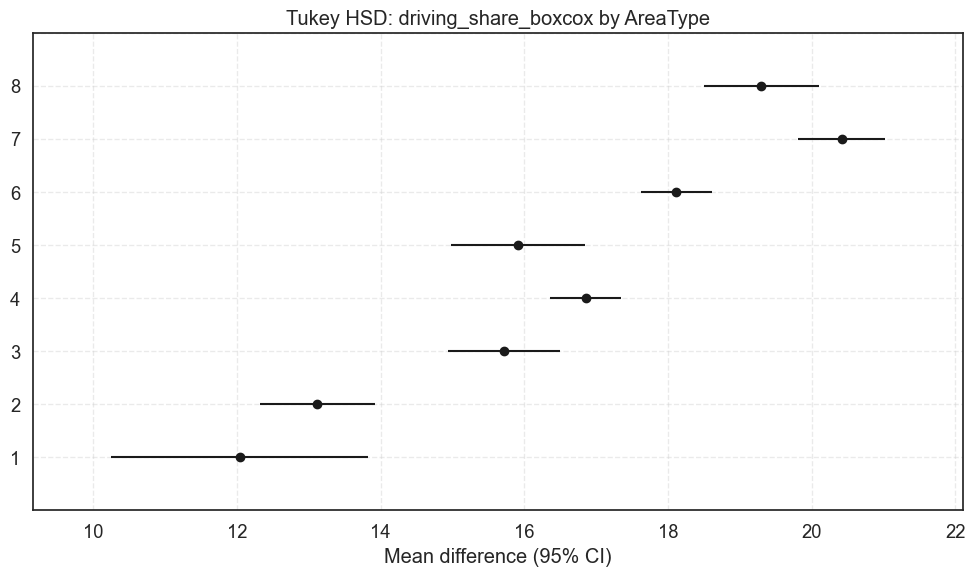


=== Tukey HSD for mean_dist_raw ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2   0.0049    1.0 -0.2989  0.3087  False
     1      3   0.2201 0.3472 -0.0824  0.5227  False
     1      4   0.4016 0.0004  0.1191  0.6841   True
     1      5   0.5093    0.0  0.1954  0.8231   True
     1      6   0.6171    0.0  0.3351  0.8992   True
     1      7   0.8269    0.0   0.537  1.1169   True
     1      8   0.6339    0.0  0.3295  0.9383   True
     2      3   0.2152 0.0132  0.0261  0.4043   True
     2      4   0.3967    0.0  0.2417  0.5517   True
     2      5   0.5043    0.0  0.2977  0.7109   True
     2      6   0.6122    0.0   0.458  0.7664   True
     2      7    0.822    0.0  0.6538  0.9902   True
     2      8    0.629    0.0  0.4369   0.821   True
     3      4   0.1815 0.0076  0.0289  0.3341   True
     3      5   0.2891 0.0005  0.0843  0.4939   True
     3   

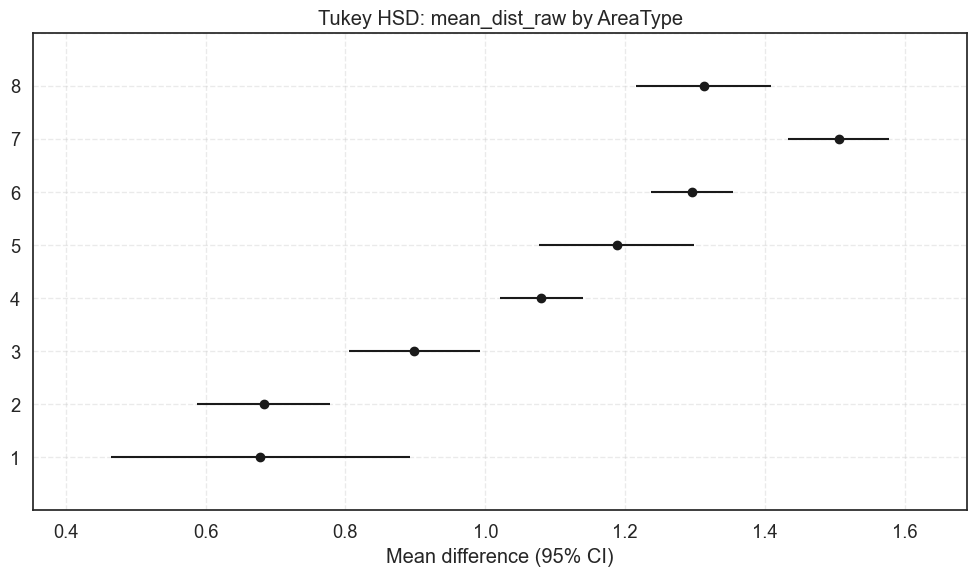


=== Tukey HSD for deliveries_boxcox ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -0.0425 0.1433 -0.0915  0.0064  False
     1      3  -0.0691 0.0005 -0.1178 -0.0203   True
     1      4  -0.0968    0.0 -0.1423 -0.0513   True
     1      5  -0.0708 0.0006 -0.1214 -0.0202   True
     1      6  -0.1166    0.0 -0.1621 -0.0712   True
     1      7  -0.1592    0.0 -0.2059 -0.1125   True
     1      8  -0.1499    0.0  -0.199 -0.1009   True
     2      3  -0.0266 0.1409  -0.057  0.0039  False
     2      4  -0.0543    0.0 -0.0792 -0.0293   True
     2      5  -0.0283 0.1654 -0.0616   0.005  False
     2      6  -0.0741    0.0 -0.0989 -0.0492   True
     2      7  -0.1167    0.0 -0.1438 -0.0896   True
     2      8  -0.1074    0.0 -0.1384 -0.0765   True
     3      4  -0.0277 0.0148 -0.0523 -0.0031   True
     3      5  -0.0017    1.0 -0.0347  0.0313  False
     

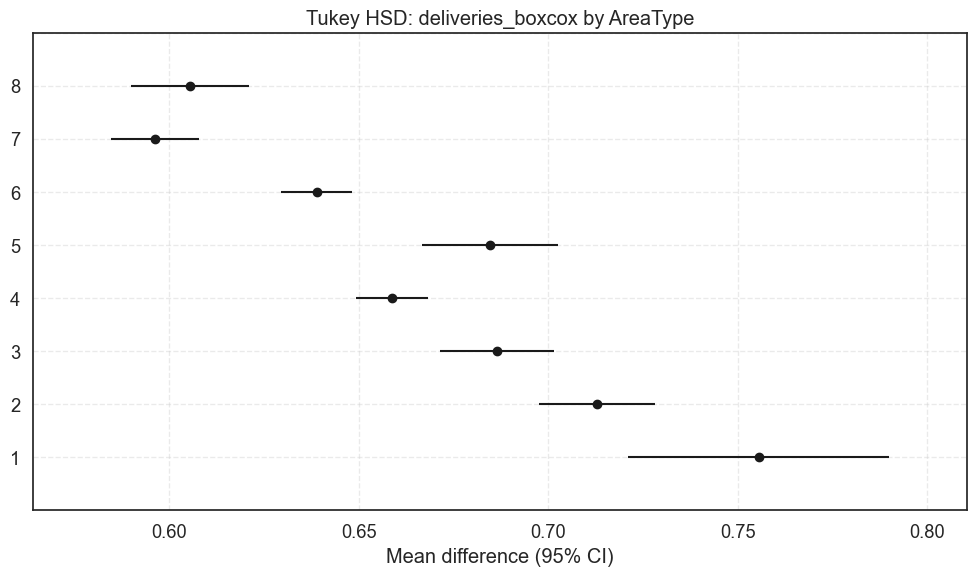


=== Tukey HSD for utilization_boxcox ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -0.0807 0.9992 -0.5091  0.3478  False
     1      3  -0.2956 0.4139 -0.7224  0.1312  False
     1      4  -0.4782 0.0068 -0.8767 -0.0797   True
     1      5   -0.366 0.1921 -0.8086  0.0767  False
     1      6  -0.5979 0.0001 -0.9958    -0.2   True
     1      7  -0.8992    0.0 -1.3082 -0.4902   True
     1      8  -0.7322    0.0 -1.1616 -0.3028   True
     2      3   -0.215 0.2201 -0.4817  0.0518  False
     2      4  -0.3975    0.0 -0.6162 -0.1789   True
     2      5  -0.2853 0.0601 -0.5768  0.0061  False
     2      6  -0.5172    0.0 -0.7348 -0.2997   True
     2      7  -0.8185    0.0 -1.0558 -0.5813   True
     2      8  -0.6516    0.0 -0.9225 -0.3807   True
     3      4  -0.1826 0.1662 -0.3979  0.0327  False
     3      5  -0.0704 0.9958 -0.3593  0.2185  False
    

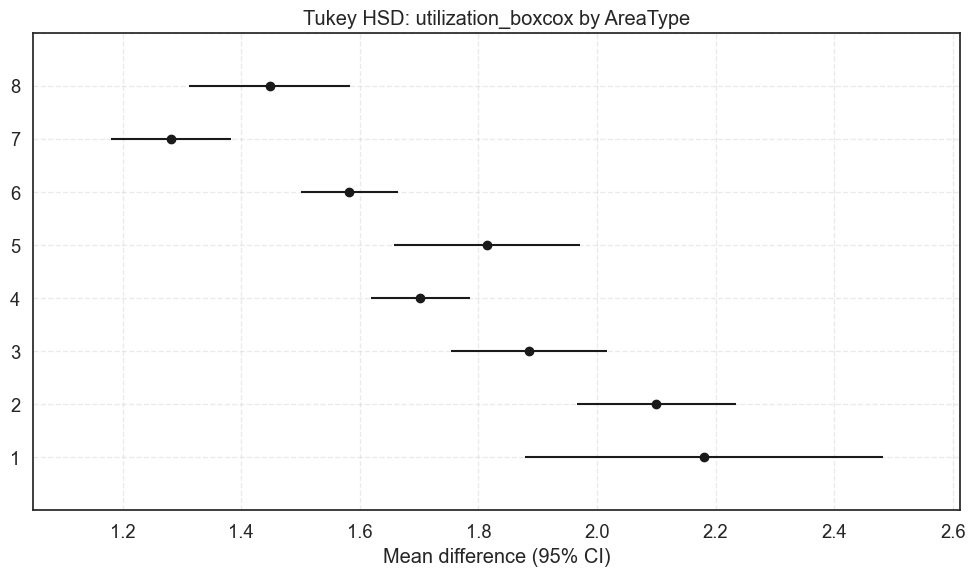

In [55]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# Falls noch nicht gesetzt:
# plt.rcParams.update({'figure.figsize': (8, 4), 'figure.dpi': 100})

# Deine abhängigen Variablen aus der MANOVA
dependent_variables = [
    'tour_length_log',          # Log-transformed Tour Length
    'average_speed',            # Raw
    'driving_share_boxcox',     # Box-Cox-transformed Driving Share
    'mean_dist_raw',            # Raw Mean Distance Between Stops
    'deliveries_boxcox',        # Box-Cox-transformed Deliveries per Stop
    'utilization_boxcox'        # Box-Cox-transformed Vehicle Utilization
]
independent_variable = 'AreaType'

for dependent_var in dependent_variables:
    print(f"\n=== Tukey HSD for {dependent_var} ===")

    # Tukey HSD Test
    tukey = pairwise_tukeyhsd(
        endog=df_rmanova[dependent_var],
        groups=df_rmanova[independent_variable],
        alpha=0.05
    )
    
    print(tukey.summary())
    
    # Plot anzeigen
    tukey.plot_simultaneous()
    plt.title(f"Tukey HSD: {dependent_var} by AreaType")
    plt.xlabel("Mean difference (95% CI)")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
